ГЕНЕРАЦИЯ ДАТАСЕТА (ДЛЯ ПРОВЕРКИ РАБОТОСПОСОБНОСТИ)

,date,product,price,quantity,sales
0,2023-01-01,Товар_A,99.72,207,20642.76
1,2023-01-02,Товар_A,104.09,231,24043.78
2,2023-01-03,Товар_A,101.57,238,24172.57
3,2023-01-04,Товар_A,104.47,283,29566.08
4,2023-01-05,Товар_A,104.80,269,28191.43
...,...,...,...,...,...
1495,2024-05-10,Товар_C,201.20,370,74445.57
1496,2024-05-11,Товар_C,198.54,328,65119.82
1497,2024-05-12,Товар_C,198.12,293,58049.53
1498,2024-05-13,Товар_C,194.58,294,57205.80



Размер датасета: (1500, 5)
Диапазон дат: 2023-01-01 00:00:00 - 2024-05-14 00:00:00

Статистика по продажам:
count     1500.000000
mean     40028.892587
std      17266.518526
min          0.000000
25%      27996.792500
50%      38298.700000
75%      50823.757500
max      93915.350000
Name: sales, dtype: float64


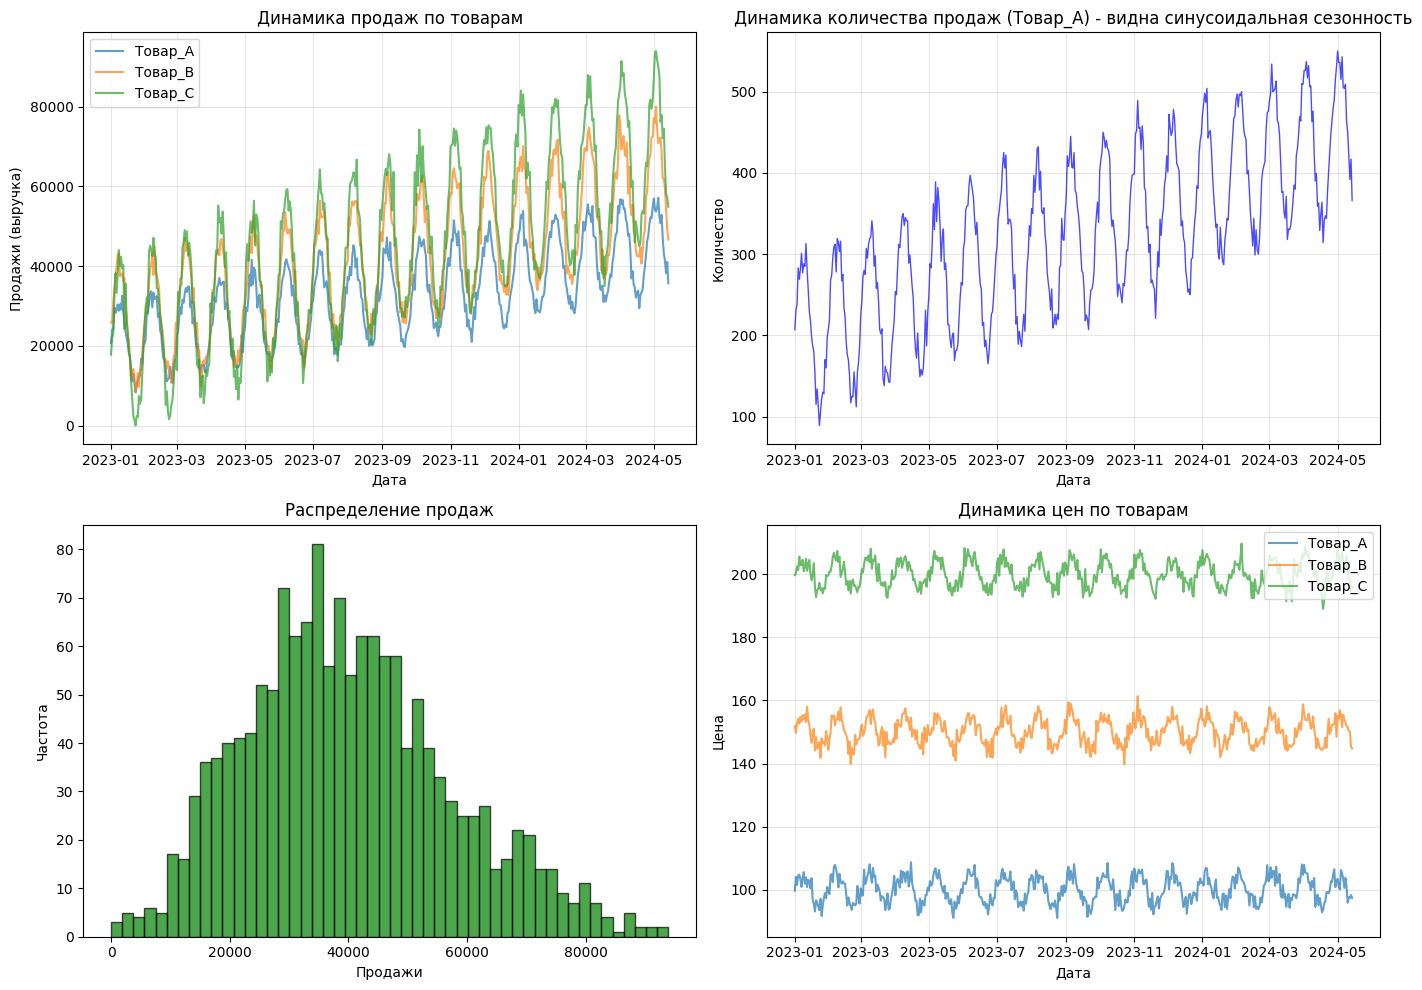

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Генерация датасета с синусоидальной сезонностью
# ============================================

np.random.seed(42)

# Параметры
n_days = 500  # количество дней
seasonal_period = 30  # период сезонности (30 дней)
amplitude = 100  # амплитуда сезонности
trend = 0.5  # линейный тренд
noise_std = 15  # стандартное отклонение шума

# Создаем даты
dates = pd.date_range(start='2023-01-01', periods=n_days, freq='D')

# Товары
products = ['Товар_A', 'Товар_B', 'Товар_C']
product_prices = {'Товар_A': 100, 'Товар_B': 150, 'Товар_C': 200}

# Базовое количество для каждого товара
base_quantity = {'Товар_A': 200, 'Товар_B': 150, 'Товар_C': 100}

# Создаем DataFrame
data = []

for product in products:
    for i, date in enumerate(dates):
        # Синусоидальная сезонность
        seasonal = amplitude * np.sin(2 * np.pi * i / seasonal_period)
        
        # Линейный тренд
        trend_component = trend * i
        
        # Случайный шум
        noise = np.random.normal(0, noise_std)
        
        # Количество продаж
        quantity = base_quantity[product] + seasonal + trend_component + noise
        quantity = max(0, int(quantity))  # количество не может быть отрицательным
        
        # Цена с небольшой сезонностью и шумом
        price = product_prices[product] + 5 * np.sin(2 * np.pi * i / seasonal_period) + np.random.normal(0, 2)
        price = max(price, product_prices[product] * 0.8)  # минимальная цена -20% от базовой
        
        # Выручка
        sales = price * quantity
        
        data.append({
            'date': date,
            'product': product,
            'price': round(price, 2),
            'quantity': quantity,
            'sales': round(sales, 2)
        })

df = pd.DataFrame(data)

display(df)
print(f"\nРазмер датасета: {df.shape}")
print(f"Диапазон дат: {df['date'].min()} - {df['date'].max()}")
print(f"\nСтатистика по продажам:")
print(df['sales'].describe())

# ============================================
# Визуализация
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Динамика продаж по товарам
for product in products:
    product_df = df[df['product'] == product]
    axes[0, 0].plot(product_df['date'], product_df['sales'], label=product, alpha=0.7)
axes[0, 0].set_title('Динамика продаж по товарам')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Продажи (выручка)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Количество продаж для Товар_A (видна сезонность)
product_a = df[df['product'] == 'Товар_A']
axes[0, 1].plot(product_a['date'], product_a['quantity'], 'b-', alpha=0.7, linewidth=1)
axes[0, 1].set_title('Динамика количества продаж (Товар_A) - видна синусоидальная сезонность')
axes[0, 1].set_xlabel('Дата')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].grid(True, alpha=0.3)

# 3. Распределение продаж (гистограмма)
axes[1, 0].hist(df['sales'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_title('Распределение продаж')
axes[1, 0].set_xlabel('Продажи')
axes[1, 0].set_ylabel('Частота')

# 4. Динамика цен по товарам
for product in products:
    product_df = df[df['product'] == product]
    axes[1, 1].plot(product_df['date'], product_df['price'], label=product, alpha=0.7)
axes[1, 1].set_title('Динамика цен по товарам')
axes[1, 1].set_xlabel('Дата')
axes[1, 1].set_ylabel('Цена')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

df.to_csv('sales_data.csv', index=False, encoding='utf-8')

ПРЕДОБРАБОТКА ДЛЯ ЛИНЕЙНОЙ РЕГРЕССИИ 

In [40]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('sales_data.csv', parse_dates=['date'])

train = df[df["date"] < "2024-01-01"].copy()
test = df[df["date"] >= "2024-01-01"].copy()

print("Размер выборок:")
print(f"  train: {len(train)} записей")
print(f"  test:  {len(test)} записей")


def preprocess_for_lr(df, is_train=True):
    df = df.copy()
    
    # Извлекаем признаки из даты
    df['day_of_week'] = df['date'].dt.dayofweek      # день недели (0=пн, 6=вс)
    df['month'] = df['date'].dt.month                # месяц (1-12)
    df['day_of_year'] = df['date'].dt.dayofyear      # день в году (1-365)
    df['weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)  # выходной ли день (1=да, 0=нет)
    
    # One-hot кодирование
    df = pd.get_dummies(df, columns=['product'], prefix='product', drop_first=False)
    
    # Убедимся, что колонки с товарами есть (на случай если в test нет какого-то товара)
    product_cols = ['product_Товар_A', 'product_Товар_B', 'product_Товар_C']
    for col in product_cols:
        if col not in df.columns:
            df[col] = 0
    
    return df

train_processed = preprocess_for_lr(train, is_train=True)
test_processed = preprocess_for_lr(test, is_train=False)

# Числовые признаки
numeric_features = ['price', 'sales', 'day_of_week', 'month', 'day_of_year', 'weekend']

# Категориальные признаки (one-hot)
product_features = ['product_Товар_A', 'product_Товар_B', 'product_Товар_C']

# Все признаки
all_features = numeric_features + product_features

# Целевая переменная
target = 'quantity'

# Разделение на выборки
X_train = train_processed[all_features]
y_train = train_processed[target]
X_test = test_processed[all_features]
y_test = test_processed[target]

print(f"\nФорма данных:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")

# Проверка на пропуски + заполнение средним значением если есть
for col in numeric_features:
    if test_processed[col].isnull().sum() > 0:
        median_val = train_processed[col].median()
        test_processed[col] = test_processed[col].fillna(median_val)

display(train_processed[['date', 'sales'] + all_features])

# Масштабирование
scaler = StandardScaler()
# scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=all_features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=all_features)

print("\nПосле масштабирования:")
display(X_train_scaled_df.head())

Размер выборок:
  train: 1095 записей
  test:  405 записей

Форма данных:
  X_train: (1095, 9)
  X_test:  (405, 9)


,date,sales,price,sales,day_of_week,month,day_of_year,weekend,product_Товар_A,product_Товар_B,product_Товар_C
0,2023-01-01,20642.76,99.72,20642.76,6,1,1,1,True,False,False
1,2023-01-02,24043.78,104.09,24043.78,0,1,2,0,True,False,False
2,2023-01-03,24172.57,101.57,24172.57,1,1,3,0,True,False,False
3,2023-01-04,29566.08,104.47,29566.08,2,1,4,0,True,False,False
4,2023-01-05,28191.43,104.80,28191.43,3,1,5,0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1360,2023-12-27,61487.45,198.99,61487.45,2,12,361,0,False,False,True
1361,2023-12-28,58140.82,204.00,58140.82,3,12,362,0,False,False,True
1362,2023-12-29,70916.42,202.04,70916.42,4,12,363,0,False,False,True
1363,2023-12-30,72995.77,205.62,72995.77,5,12,364,1,False,False,True



После масштабирования:


,price,sales,day_of_week,month,day_of_year,weekend,product_Товар_A,product_Товар_B,product_Товар_C
0,-1.227748,-0.959526,1.493348,-1.602745,-1.727312,1.573592,1.414214,-0.707107,-0.707107
1,-1.121294,-0.729066,-1.501553,-1.602745,-1.717821,-0.635489,1.414214,-0.707107,-0.707107
2,-1.182682,-0.720339,-1.002403,-1.602745,-1.708330,-0.635489,1.414214,-0.707107,-0.707107
3,-1.112038,-0.354864,-0.503253,-1.602745,-1.698840,-0.635489,1.414214,-0.707107,-0.707107
4,-1.103999,-0.448013,-0.004103,-1.602745,-1.689349,-0.635489,1.414214,-0.707107,-0.707107


МОДЕЛЬКА
1. ЛИНЕЙНАЯ РЕГРЕССИЯ - BASELINE

In [43]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_absolute_error

print("Linear Regression")

lr = LinearRegression()
lr.fit(X_train_scaled_df, y_train)

y_train_pred_lr = lr.predict(X_train_scaled_df)
y_test_pred_lr = lr.predict(X_test_scaled_df)

r2_train_lr = r2_score(y_train, y_train_pred_lr)
r2_test_lr = r2_score(y_test, y_test_pred_lr)
mae_lr = mean_absolute_error(y_test, y_test_pred_lr)

print(f"    R² на обучающей выборке: {r2_train_lr:.4f}")
print(f"    R² на тестовой выборке:  {r2_test_lr:.4f}")
print(f"    MAE на тестовой выборке: {mae_lr:.2f}")

Linear Regression
    R² на обучающей выборке: 0.9605
    R² на тестовой выборке:  0.4259
    MAE на тестовой выборке: 57.03
